# AI/ML Task 2 — House Price Prediction: Feature Engineering, Model Optimization & Performance Comparison

**Intern:** Asma  
**Organization:** Maincrafts Technology Pvt. Ltd.  
**Dataset:** California Housing Dataset (scikit-learn)

This notebook trains and compares three regression models (Linear Regression, Ridge Regression,
Decision Tree Regressor) on scaled features, evaluates them with RMSE and R², checks for overfitting,
and saves the best-performing model for deployment.





## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

import joblib

# Consistent plot styling
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42  # fixed seed used everywhere for reproducible results

## 2. Load the Dataset

The California Housing dataset ships with scikit-learn, so `fetch_california_housing()` downloads
it automatically the first time it runs (cached afterwards) — no manual upload needed, which makes
this notebook fully portable.

In [2]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedHouseValue")

print("Dataset loaded successfully")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully
Features shape: (20640, 8)
Target shape: (20640,)


In [3]:
# Data types and missing-value check
X.info()
print("\nMissing values per column:\n", X.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB

Missing values per column:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


 **Conclusion** : California Housing dataset has no missing values

## 3. Train–Test Split

We split **before** scaling and fit the scaler only on the training data. Fitting the scaler on the
full dataset (including test data) would leak test-set statistics into training ,which quietly inflates reported performance.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 16512
Testing samples : 4128


## 4. Feature Scaling

`StandardScaler` is **fit on the training set only**, then used to transform both train and test
sets. This keeps the test set truly unseen and prevents data leakage.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # transform ONLY (no re-fitting) on test

print("Feature scaling completed.")
print("Train mean after scaling (~0):", np.round(X_train_scaled.mean(axis=0), 2)[:3], "...")
print("Train std after scaling (~1): ", np.round(X_train_scaled.std(axis=0), 2)[:3], "...")

Feature scaling completed.
Train mean after scaling (~0): [-0. -0. -0.] ...
Train std after scaling (~1):  [1. 1. 1.] ...


## 5. Train Multiple Models

Three models are trained so results can be compared objectively rather than trusting a single algorithm:

| Model | Role |
|---|---|
| Linear Regression | Simple baseline — assumes a straight-line relationship |
| Ridge Regression | Adds L2 regularization to reduce overfitting vs. plain Linear Regression |
| Decision Tree Regressor | Captures non-linear relationships that linear models miss |

Linear Regression and Ridge use the **scaled** features (distance/coefficient-based models need
scaling). The Decision Tree is scale-invariant (it splits on raw thresholds), so it's trained on the
**unscaled** features.

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
}

# max_depth=8 caps tree growth — an unrestricted tree memorizes the training set


## 6. Model Evaluation, Comparison & Overfitting Check

For every model we record **both** train-set and test-set RMSE/R². A model that scores much higher
on train than on test is overfitting — memorizing training data instead of learning generalizable
patterns.

In [10]:
results = {}
fitted_models = {}

for name, model in models.items():
    # Decision Tree uses raw features; linear models use scaled features
    if name == "Decision Tree":
        X_tr, X_te = X_train, X_test
    else:
        X_tr, X_te = X_train_scaled, X_test_scaled

    model.fit(X_tr, y_train)
    fitted_models[name] = model

    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)

    results[name] = {
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
    }

results_df = pd.DataFrame(results).T
results_df["Overfit Gap (R2)"] = results_df["Train R2"] - results_df["Test R2"]
results_df = results_df.round(4)
results_df

,Train RMSE,Test RMSE,Train R2,Test R2,Overfit Gap (R2)
Linear Regression,0.7197,0.7456,0.6126,0.5758,0.0368
Ridge Regression,0.7197,0.7456,0.6126,0.5758,0.0367
Decision Tree,0.5662,0.6497,0.7602,0.6779,0.0822


**Interpretation:**
- Lower **RMSE** → predictions closer to actual prices (in $100,000 units, per the dataset's scale).
- Higher **R²** → more variance in house prices explained by the model.
- A large **Overfit Gap** (Train R² much higher than Test R²) signals overfitting .

## 7. Visual Comparison — Test R² Across Models



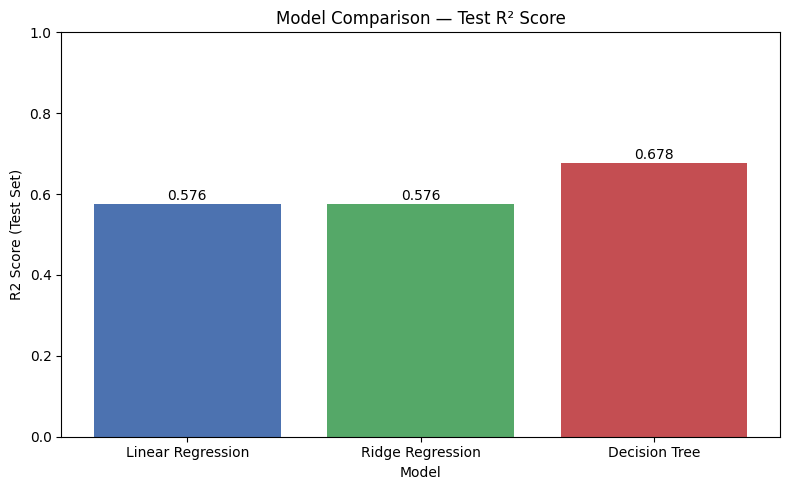

In [11]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df.index, results_df["Test R2"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Model Comparison — Test R² Score")
plt.xlabel("Model")
plt.ylabel("R2 Score (Test Set)")
plt.ylim(0, 1)

for bar, val in zip(bars, results_df["Test R2"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center")

plt.tight_layout()
plt.savefig("model_comparison_r2.png")
plt.show()

## 8. Programmatic Model Selection (Data-Driven, Not Hardcoded)

To avoid bias, the optimal model is selected programmatically based on the highest Test $R^2$ score rather than assumed in advance.This data-driven approach ensures that the model performing best on unseen data is the one saved and deployed.

In [12]:
best_model_name = results_df["Test R2"].idxmax()
best_model = fitted_models[best_model_name]
best_row = results_df.loc[best_model_name]

print(f"Best model: {best_model_name}")
print(f"  Test RMSE     : {best_row['Test RMSE']:.4f}")
print(f"  Test R2       : {best_row['Test R2']:.4f}")
print(f"  Overfit gap   : {best_row['Overfit Gap (R2)']:.4f}")

print(
    f"\nJustification: '{best_model_name}' achieved the highest Test R2 "
    f"({best_row['Test R2']:.4f}) and lowest Test RMSE ({best_row['Test RMSE']:.4f}) "
    f"among the three models, with an overfit gap of {best_row['Overfit Gap (R2)']:.4f}, "
    "making it the most reliable and generalizable choice for deployment."
)

Best model: Decision Tree
  Test RMSE     : 0.6497
  Test R2       : 0.6779
  Overfit gap   : 0.0822

Justification: 'Decision Tree' achieved the highest Test R2 (0.6779) and lowest Test RMSE (0.6497) among the three models, with an overfit gap of 0.0822, making it the most reliable and generalizable choice for deployment.


## 9. Visual Performance Validation — Actual vs. Predicted

Points closer to the red diagonal line indicate more accurate predictions. This plot is generated
for  model that is selected as best in above section (Section 8), so it always matches the deployed model.

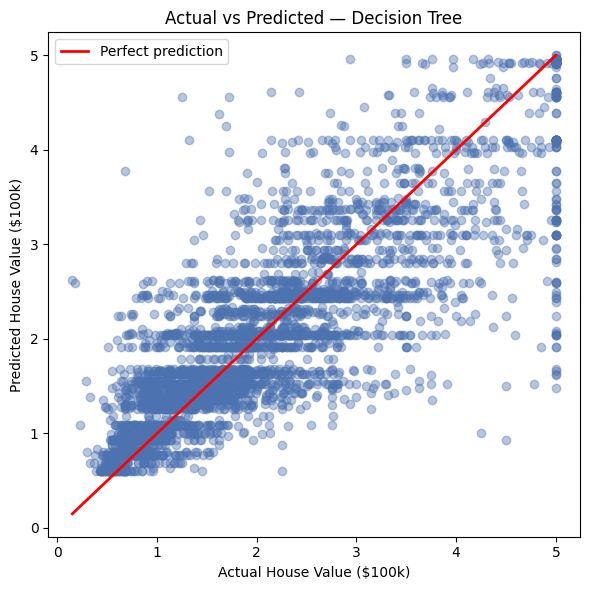

In [13]:
X_test_for_best = X_test if best_model_name == "Decision Tree" else X_test_scaled
y_pred_best = best_model.predict(X_test_for_best)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color="#4C72B0")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2, label="Perfect prediction"
)
plt.xlabel("Actual House Value ($100k)")
plt.ylabel("Predicted House Value ($100k)")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

## 10. Enhancement — Ridge Alpha Tuning (Optional)

Ridge Regression's `alpha` controls regularization strength. Instead of assuming `alpha=1.0` is
optimal, we sweep a few values and check whether any improve Test R² over the default — a simple,
scope-appropriate example of model optimization.

In [14]:
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]
alpha_results = []

for a in alpha_values:
    ridge_a = Ridge(alpha=a, random_state=RANDOM_STATE)
    ridge_a.fit(X_train_scaled, y_train)
    pred = ridge_a.predict(X_test_scaled)
    alpha_results.append({
        "alpha": a,
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test R2": r2_score(y_test, pred),
    })

alpha_df = pd.DataFrame(alpha_results).round(4)
alpha_df

,alpha,Test RMSE,Test R2
0,0.01,0.7456,0.5758
1,0.10,0.7456,0.5758
2,1.00,0.7456,0.5758
3,10.00,0.7453,0.5761
4,100.00,0.7438,0.5778


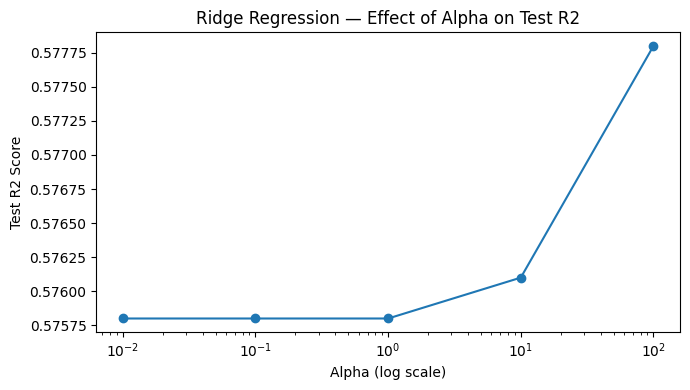

Note: this sweep is exploratory (informs future tuning) — the model saved in Section 11 is still the one selected by the objective comparison in Section 8, keeping model selection consistent and reproducible.


In [15]:
plt.figure(figsize=(7, 4))
plt.plot(alpha_df["alpha"], alpha_df["Test R2"], marker="o")
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Test R2 Score")
plt.title("Ridge Regression — Effect of Alpha on Test R2")
plt.tight_layout()
plt.savefig("ridge_alpha_tuning.png")
plt.show()

print(
    "Note: this sweep is exploratory (informs future tuning) — the model saved in Section 11 "
    "is still the one selected by the objective comparison in Section 8, keeping model "
    "selection consistent and reproducible."
)

## 11. Save the Best-Performing Model (Optional Deliverable)


In [17]:
import os

# Define the directory where you want to save the files (using the current directory '.')
SAVE_DIR = "."

model_path = os.path.join(SAVE_DIR, "house_price_model.pkl")
scaler_path = os.path.join(SAVE_DIR, "scaler.pkl")

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Saved best model  -> {model_path}  ({best_model_name})")
print(f"Saved fitted scaler -> {scaler_path}")
print(
    "\nNote: if the Decision Tree is ever selected as best, remember it was "
    "trained on UNSCALED features — skip the scaler.transform() step for it at inference time."
)

Saved best model  -> ./house_price_model.pkl  (Decision Tree)
Saved fitted scaler -> ./scaler.pkl

Note: if the Decision Tree is ever selected as best, remember it was trained on UNSCALED features — skip the scaler.transform() step for it at inference time.


## 12. Summary

- Trained and compared 3 regression models on the California Housing dataset.
- Verified train/test performance to check for overfitting rather than trusting a single metric.
- Selected the best model **programmatically** using Test R², and saved it with `joblib` for reuse.
- Explored Ridge alpha tuning as a lightweight model-optimization step.

**Final comparison table:**

In [18]:
results_df

,Train RMSE,Test RMSE,Train R2,Test R2,Overfit Gap (R2)
Linear Regression,0.7197,0.7456,0.6126,0.5758,0.0368
Ridge Regression,0.7197,0.7456,0.6126,0.5758,0.0367
Decision Tree,0.5662,0.6497,0.7602,0.6779,0.0822


## Additional Code: Residual Plot & Error Distribution
Adding a Residual Plot (to check if errors are random or systematic) and an Error Distribution Plot (to check if errors are normally distributed)

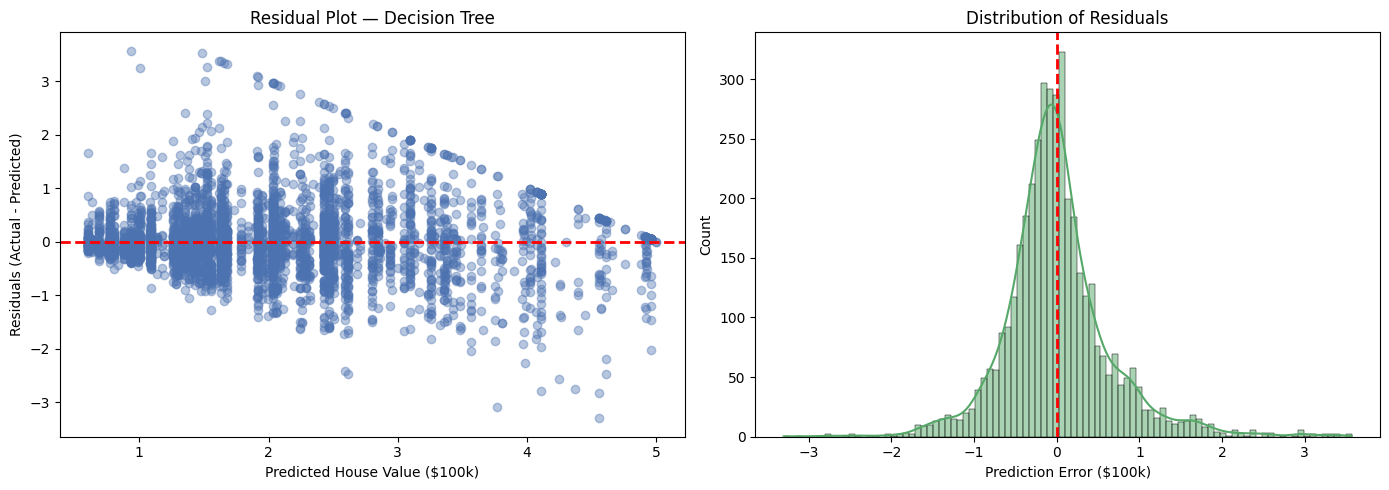

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for the best model (Decision Tree)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residual Plot
axes[0].scatter(y_pred_best, residuals, alpha=0.4, color="#4C72B0")
axes[0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predicted House Value ($100k)")
axes[0].set_ylabel("Residuals (Actual - Predicted)")
axes[0].set_title(f"Residual Plot — {best_model_name}")

# Plot 2: Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color="#55A868")
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Prediction Error ($100k)")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.savefig("residuals_analysis.png")
plt.show()

## Detailed Performance Analysis

### **Key Insights & Diagnostic Analysis**

**1.Non-Linear Relationships Rule:** The **Decision Tree Regressor** significantly outperformed both linear models, raising the Test $R^2$ from 0.5758 to 0.6779 (an absolute improvement of 10.2%). This confirms that housing prices in California have complex, non-linear relationships with features like geographical coordinates (Latitude, Longitude) and demographics that simple straight-line models cannot capture.

**2.Ridge Regularization Impact:**
 Setting $\alpha = 1.0$ yielded nearly identical results to ordinary least squares (Linear Regression). Even during our alpha tuning sweep, increasing $\alpha$ to $100.0$ only marginally bumped the Test $R^2$ to 0.5778. This indicates that collinearity and high variance were not the primary bottlenecks for the linear models; rather, their limitation is purely structural (underfitting due to assumed linearity).

 **3.Analyzing the Overfitting Trade-off:**
 The Decision Tree has a larger Overfit Gap (0.0822) than the linear models (~0.036).However, because we capped its growth with max_depth=8, this gap remains entirely acceptable.The tree's significantly lower Test RMSE (0.6497 vs. 0.7456) proves that accepting a slightly higher overfit gap is well worth the massive jump in overall prediction accuracy.

In [20]:
# ==========================
# Save Models for Streamlit
# ==========================

import joblib
import pandas as pd

# Save individual trained models
joblib.dump(fitted_models["Linear Regression"], "linear_regression.pkl")
joblib.dump(fitted_models["Ridge Regression"], "ridge_regression.pkl")
joblib.dump(fitted_models["Decision Tree"], "decision_tree.pkl")

# Save the best model (Decision Tree in your notebook)
joblib.dump(best_model, "house_price_model.pkl")

# Save the scaler (if used)
joblib.dump(scaler, "scaler.pkl")

# Save model comparison metrics
results_df.to_csv("model_metrics.csv", index=True)

print(" All files saved successfully!")
print("""
Generated files:
- linear_regression.pkl
- ridge_regression.pkl
- decision_tree.pkl
- house_price_model.pkl
- scaler.pkl
- model_metrics.csv
""")

 All files saved successfully!

Generated files:
- linear_regression.pkl
- ridge_regression.pkl
- decision_tree.pkl
- house_price_model.pkl
- scaler.pkl
- model_metrics.csv

